# <center>Metody Numeryczne</center>

# Laboratorium 12: Równania różniczkowe


**Wykonał:** Aleksander Młynarski

<br>

### **Metoda zaliczenia:**

Podczas zajęć należy wykonać poniższe polecenia oraz udzielić odpowiedzi na pytania zamieszczone w treści zadań. 

Wszystkie funkcje wymagane w ramach ćwiczenia należy zaimplementować w pliku `main.py`. Poprawność ich działania należy zweryfikować za pomocą testów jednostkowych dostępnych w pliku `test_main.py`.

### **Cel zajęć:**

Celem zajęć jest zapoznanie się z numerycznymi metodami rozwiązywania równań różniczkowych zwyczajnych. 

W ramach laboratorium rozpatrywane będą równania różniczkowe postaci:
$$
\dot{x}(t) = f(x(t), t)
$$
gdzie:

$x(t) \in \mathbb{R}^n$,  $t \ge 0$ 


z warunkiem początkowym $x(0) = x_0$.

Jest to tak zwany problem początkowy ([problem Cauchy’ego](https://en.wikipedia.org/wiki/Cauchy_problem)) dla równań różniczkowych zwyczajnych.


### **Uwagi wstępne:**
- Funkcje wymagające implementacji (lub zaimplementowane na poprzednich laboratoriach) oznaczone są pochyłą czcionką maszynową (np. *`my_func()`*).

- Dla poprawienia czytelności wyrażeń matematycznych funkcje czasu we wzorach definiujących układy równań różniczkowych są opisane z pominięciem zmiennej czasowej: $[\dot{x}_1(t) = x_2(t)^2] \rightarrow [\dot{x}_1 = {x_2}^2]$.

- W skrypcie stosuje się następujące skróty:

    - `np` - `numpy`,
    - `sp` - `scipy`.

---

In [18]:
# !python -m pip install numpy scipy matplotlib

import main

import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

---

### **Zadanie 1.**

Zaimplementuj funkcję *`solve_euler()`* rozwiązującą układ równań różniczkowych metodą [Eulera w przód](https://en.wikipedia.org/wiki/Euler_method).

---

### **Zadanie 2.**

Dane jest równanie różniczkowe:
$$
\dot{x} = \frac{x+t}{x-t}
$$

Dla warunku początkowego $x(0) = 1$ równanie to posiada rozwiązanie dokładne: 
$$
x(t) = t + \sqrt{1 + 2t^2}
$$

1. Rozwiąż podane równanie metodą z **Zadania 1.** dla kroków czasowych: $1\mathrm{e}{1}$, $1\mathrm{e}{-2}$ i $1\mathrm{e}{-5}$.

2. Narysuj wykres podanego rozwiązania dokładnego oraz uzyskanych rozwiązań numerycznych.

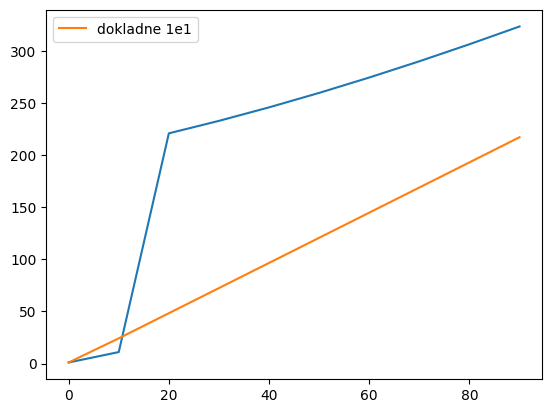

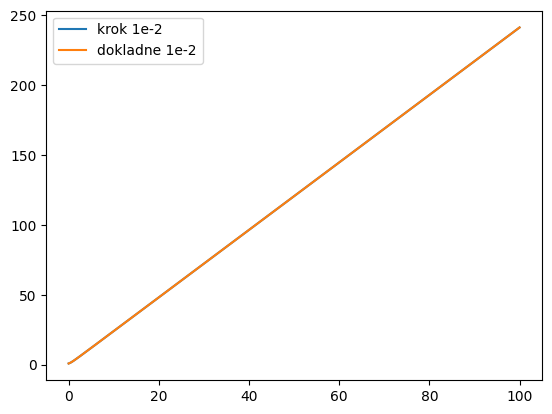

C:\Users\alekm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


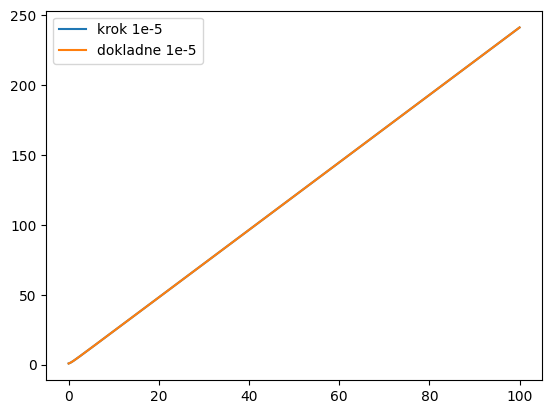

In [19]:

krok1 = 1e1
krok2 = 1e-2
krok3 = 1e-5

def f(t, y):
    return (y + t) / (y - t)

def g(t):
    d = np.zeros(t.size)
    for x in range (0, t.size):
        d[x] = t[x] + np.sqrt(1 + 2 * t[x]**2)
    return d

y0 = np.array([1.0])
t1 = np.arange(0, 100, krok1)
t2 = np.arange(0, 100, krok2)
t3 = np.arange(0, 100, krok3)
y1 = main.solve_euler(f, t1, y0)
y2 = main.solve_euler(f, t2, y0)
y3 = main.solve_euler(f, t3, y0)

y1_prim = g(t1)
y2_prim = g(t2)
y3_prim = g(t3)

plt.plot(t1, y1[0, :])
plt.plot(t1, y1_prim, label='dokladne 1e1')
plt.legend()
plt.show()

plt.plot(t2, y2[0, :], label='krok 1e-2')
plt.plot(t2, y2_prim, label='dokladne 1e-2')
plt.legend()
plt.show()

plt.plot(t3, y3[0, :], label='krok 1e-5')
plt.plot(t3, y3_prim, label='dokladne 1e-5')
plt.legend()
plt.show()

---

### **Zadanie 3.**

Dany jest układ równań różniczkowych:

$$
\begin{cases}
\begin{align*}
    \dot{x}_1&={x_3}\\
    \dot{x}_2&={x_4}\\
    \dot{x}_3&=-\frac{x_1}{{({x_1}^2+{x_2}^2)}^{\frac{3}{2}}}\\
    \dot{x}_4&=-\frac{x_2}{{({x_1}^2+{x_2}^2)}^{\frac{3}{2}}}
\end{align*}
\end{cases}
$$

Dla warunku początkowego $x(0)=[1,0,0,1]^T$ układ ten posiada rozwiązanie dokładne:
$$
x(t)=
\left[
\begin{matrix}
\begin{align*}
    &\cos(t)\\
    &\sin(t)\\
    -&\sin(t)\\
    &\cos(t)
\end{align*}
\end{matrix}
\right]
$$

1. Rozwiąż układ równań metodą z **Zadania 1.** dla kroków czasowych: $1\mathrm{e}{1}$, $1\mathrm{e}{-2}$ i $1\mathrm{e}{-5}$.

2. Narysuj wykres podanego rozwiązania dokładnego oraz uzyskanych rozwiązań numerycznych.

3. Sprawdź po jakim czasie $t$ rozwiązania numeryczne przestaną dawać zadowalające wyniki. W tym celu zbadaj błąd rozwiązania numerycznego względem dokładnego.

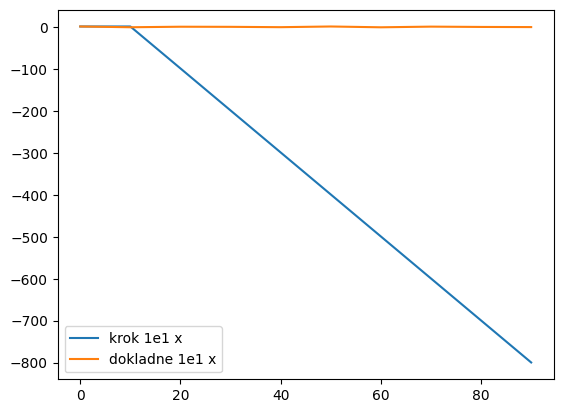

In [20]:
krok1 = 1e1
krok2 = 1e-2
krok3 = 1e-5
def f(t, y):
    wynik = np.zeros(4)
    wynik[0] = y[2]
    wynik[1] = y[3]
    wynik[2] = -y[0] / ((y[0]**2+y[1]**2)**1.5)
    wynik[3] = -y[1] / ((y[0]**2+y[1]**2)**1.5)
    return wynik

def g(t):
    return np.array((np.cos(t),np.sin(t),-np.sin(t),np.cos(t)))
y0 = np.array([1, 0, 0, 1])
t1 = np.arange(0, 100, krok1)
t2 = np.arange(0, 100, krok2)
t3 = np.arange(0, 100, krok3)
y1 = main.solve_euler(f, t1, y0)
y2 = main.solve_euler(f, t2, y0)
y3 = main.solve_euler(f, t3, y0)
y1_prim = g(t1)
y2_prim = g(t2)
y3_prim = g(t3)
plt.plot(t1, y1[0,:], label='krok 1e1 x')
plt.plot(t1, y1_prim[0,:], label='dokladne 1e1 x')
plt.legend()
    

---

### **Zadanie 4.**

Używając układu równań różniczkowych z **Zadania 3.** wykonaj polecenia.

1. Rozwiąż układ równań używając solverów *RK45* i *RK23* zaimplementowanych w funkcji [`sp.integrate.solve_ivp()`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html). Porównaj wyniki dla takiego samego przedziału czasu.

2. Sprawdź ile razy każda z metod obliczała równanie prawej strony (parametr `nfev`). Odnieś to do analogicznej liczby z metody z poprzedniego zadania.

3. Dla wybranej metody zbadaj wpływ parametru `rtol` na rozwiązanie.

---

### **Zadanie 5.**

Orbita Arenstorfa. Jest to przykład z astronomii opisujący zredukowany problem trzech ciał. Rozważa się dwa ciała o masach $\mu$ i $\mu'=1-\mu$, poruszające się w ruchu kołowym na jednej płaszczyźnie oraz ciało o pomijalnej masie poruszające się między nimi w tej samej płaszczyźnie. 

Zmienne $x_1$ i $x_3$ odpowiadają za współrzędne na płaszczyźnie trzeciego ciała, zaś $x_2$ i $x_4$ są współrzędnymi prędkości. Warto zwrócić uwagę, że zarówno czas jak i masa zostały w równaniach przeskalowane i nie mają bezpośredniej interpretacji fizycznej, należy je traktować jako zmienne bezwymiarowe. 

Dany jest układ równań różniczkowych:
$$
\begin{cases}
\begin{align*}
    \dot{x}_1 &= x_2\\
    \dot{x}_2 &= x_1 + 2x_4 - \mu'\frac{x_1+\mu}{D_1} - \mu\frac{x_1-\mu'}{D_2}\\
    \dot{x}_3 &= x_4\\
    \dot{x}_4 &= x_3 - 2x_2 - \mu'\frac{x_3}{D_1} - \mu\frac{x_3}{D_2}
\end{align*}
\end{cases}
$$

gdzie:
$$
\begin{align*}
    D_1 &= ((x_1 + \mu)^2+{x_3}^2)^\frac{3}{2}\\
    D_2 &= ((x_1 - \mu')^2+{x_3}^2)^\frac{3}{2}\\
    \mu &= 0.012277471
\end{align*}
$$


Dla warunku początkowego $x(0) = [0.994, 0, 0, −2.00158510637908252240537862224]^T$ układ ten posiada rozwiązanie dokładne, które zarazem jest rozwiązaniem okresowym:
$$
x(0)=x(T)\\
T = 17.0652165601579625588917206249
$$

<br>

1. Zaimplementuj funkcję *`arenstorf()`* opisującą powyższy układ równań.

2. Narysuj wykres uzyskanych rozwiązań numerycznych.

In [21]:
# Wartości stałych do Zadania 5.
mu = 0.012277471
x0 = np.array([0.994, 0, 0, -2.00158510637908252240537862224])
T = 17.0652165601579625588917206249

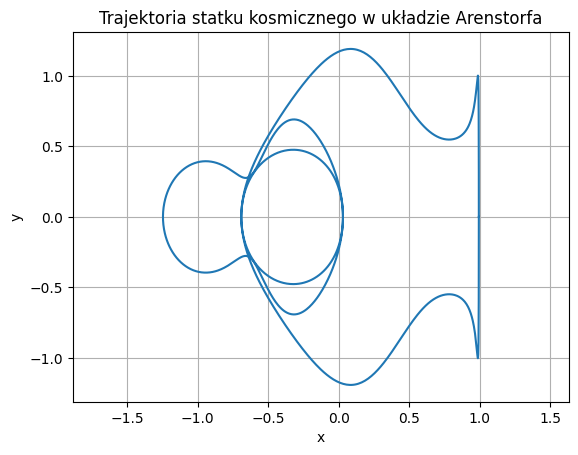

In [25]:
sol_arenstorf = solve_ivp(
    main.arenstorf, 
    (0, T), 
    x0, 
    method='RK45', 
    rtol=1e-9, 
    atol=1e-12,
    max_step=0.01
)
plt.plot(sol_arenstorf.y[0], sol_arenstorf.y[1])
plt.title("Trajektoria statku kosmicznego w układzie Arenstorfa")
plt.xlabel("x")
plt.ylabel("y")
plt.axis('equal')
plt.grid()
plt.show()


---

**Bibliografia**

1. J. C. Butcher. Numerical Methods for Ordinary Differential Equations. John Wiley and Sons, Ltd., 2003.
2. Z. Fortuna, B. Macukow, and J. Wąsowski. Metody numeryczne. WNT Warszawa, 1982.
3. E. Hairer, S.P. Nørsett, and G. Wanner. Solving Ordinary Differential Equations: I Nonstiff problems. Springer, 2 edition, 2000.
4. W. Mitkowski. Równania macierzowe i ich zastosowania. Wydawnictwa AGH, Kraków, 2 edition, 2007.
5. A. Ralston. Wstęp do analizy numerycznej. PWN, Warszawa, 1965.
6. L. F. Shampine, I. Gladwell, and S. Thompson. Solving ODEs with MATLAB. Cambridge University Press, 2003.
7. Stoer, J., Burlirsch, R., 1980: Wstęp do metod numerycznych, tom 2. PWN Warszawa.


**Materiały uzupełniające:**
- [Scipy Lecture Notes](http://www.scipy-lectures.org/index.html)
- [NumPy for Matlab users](https://docs.scipy.org/doc/numpy/user/numpy-for-matlab-users.html#numpy-for-matlab-users)
- [Python Tutorial - W3Schools](https://www.w3schools.com/python/default.asp)
- [NumPy](https://www.numpy.org)
- [Matplotlib](https://matplotlib.org/)
- [Anaconda](https://www.anaconda.com/)
- [Learn Python for Data Science](https://www.datacamp.com/learn-python-with-anaconda?utm_source=Anaconda_download&utm_campaign=datacamp_training&utm_medium=banner)
- [Learn Python](https://www.learnpython.org/)
- [Wujek Google](https://google.pl) i [Ciocia Wikipedia](https://pl.wikipedia.org/wiki/Wikipedia:Strona_g%C5%82%C3%B3wna)